In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/final-model-pth/model_final_new.pth
/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/README.dataset.txt
/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/README.roboflow.txt
/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/data.yaml
/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/app.py
/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/valid/labels/67_png.rf.3ff8e2d78b2267ddd4942c79ee080f2d.txt
/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/valid/labels/29_png.rf.d12ebcf07583077f6853830a56ba649e.txt
/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/valid/labels/40_png.rf.f621914519e439b936bebc9cece2cfd3.txt
/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/valid/labels/148-b_png.rf.3d0f091593b5e22a2ae9796e968a799b.txt
/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/valid/labels/9_png.rf.ad6ba551ff28ad563abb479595c7f817.txt
/kaggle/input/microplasti

In [107]:
!pip install torch torchvision
!pip install matplotlib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-1

In [18]:
import os
import json
import cv2
from tqdm import tqdm

# Define paths
train_img_folder = '/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/train/images'
train_label_folder = '/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/train/labels'
val_img_folder = '/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/valid/images'
val_label_folder = '/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/valid/labels'
test_img_folder = '/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/test/images'
test_label_folder = '/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/test/labels'

# Class names
class_names = ['fiber', 'film', 'fragment', 'pellet']

# Convert a single YOLO label file to COCO annotations
def yolo_to_coco_format(img_id, img_filename, label_path, class_names, ann_id_start):
    coco_annotations = []
    img = cv2.imread(img_filename)
    if img is None:
        return [], ann_id_start
    h, w, _ = img.shape

    with open(label_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if not line.strip():
                continue
            cls_id, x_center, y_center, box_w, box_h = map(float, line.strip().split())
            x_min = (x_center - box_w / 2) * w
            y_min = (y_center - box_h / 2) * h
            width = box_w * w
            height = box_h * h
            category_id = int(cls_id) + 1  # COCO IDs start at 1

            coco_annotations.append({
                "id": ann_id_start,
                "image_id": img_id,
                "category_id": category_id,
                "bbox": [x_min, y_min, width, height],
                "area": width * height,
                "iscrowd": 0,
                "segmentation": []
            })
            ann_id_start += 1

    return coco_annotations, ann_id_start

# Convert full YOLO dataset split to COCO format
def convert_to_coco_format(image_folder, label_folder, split):
    images = []
    annotations = []
    img_id = 0
    ann_id = 1  # COCO requires annotation IDs to start from 1

    image_files = [f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
    image_files.sort()  # To ensure consistent ordering

    for img_filename in tqdm(image_files, desc=f"Processing {split}"):
        img_path = os.path.join(image_folder, img_filename)
        label_filename = os.path.splitext(img_filename)[0] + '.txt'
        label_path = os.path.join(label_folder, label_filename)

        if not os.path.exists(label_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w, _ = img.shape

        images.append({
            "id": img_id,
            "file_name": img_filename,
            "width": w,
            "height": h
        })

        coco_annots, ann_id = yolo_to_coco_format(img_id, img_path, label_path, class_names, ann_id)
        annotations.extend(coco_annots)
        img_id += 1

    coco_format = {
        "images": images,
        "annotations": annotations,
        "categories": [{"id": i + 1, "name": name} for i, name in enumerate(class_names)]
    }

    out_json = f'coco_{split}_annotations.json'
    with open(out_json, 'w') as f:
        json.dump(coco_format, f)

    print(f'✔ COCO format for {split} saved: {out_json}')

    return coco_format

# Convert all splits
convert_to_coco_format(train_img_folder, train_label_folder, 'train')
convert_to_coco_format(val_img_folder, val_label_folder, 'val')
convert_to_coco_format(test_img_folder, test_label_folder, 'test')


Processing train: 100%|██████████| 315/315 [00:02<00:00, 113.55it/s]


✔ COCO format for train saved: coco_train_annotations.json


Processing val: 100%|██████████| 37/37 [00:00<00:00, 167.60it/s]


✔ COCO format for val saved: coco_val_annotations.json


Processing test: 100%|██████████| 9/9 [00:00<00:00, 166.88it/s]

✔ COCO format for test saved: coco_test_annotations.json


{'images': [{'id': 0,
   'file_name': '100_png.rf.9cc6749d84a327fc52c47b16e1818b5f.jpg',
   'width': 640,
   'height': 640},
  {'id': 1,
   'file_name': '104_png.rf.ec4057e0614b9812ad467c5bf81847cf.jpg',
   'width': 640,
   'height': 640},
  {'id': 2,
   'file_name': '127-b_png.rf.27fa2110d6c8eb7343ea85237953f276.jpg',
   'width': 640,
   'height': 640},
  {'id': 3,
   'file_name': '145-b_png.rf.6acde7f023394c95f52f67fcabadadd7.jpg',
   'width': 640,
   'height': 640},
  {'id': 4,
   'file_name': '46_png.rf.14ce4c4e2f0842a83871a1ba425a11ba.jpg',
   'width': 640,
   'height': 640},
  {'id': 5,
   'file_name': '51_png.rf.a0b84a6ad57c08fff93562cf7a83594e.jpg',
   'width': 640,
   'height': 640},
  {'id': 6,
   'file_name': '54_png.rf.c0893ed5fa0ea945f6305dbc121a1d4f.jpg',
   'width': 640,
   'height': 640},
  {'id': 7,
   'file_name': '57_png.rf.169d7afb864ceeaf715e6bde20b0bd97.jpg',
   'width': 640,
   'height': 640},
  {'id': 8,
   'file_name': '86_png.rf.5ac30856c3fb547dc617610ba5fca43

In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import ToTensor
from torchvision.datasets import CocoDetection

In [19]:


# --- Fixed Dataset Class ---
class CocoDetectionFixed(CocoDetection):
    def __init__(self, img_folder, ann_file, transforms=None):
        super().__init__(img_folder, ann_file)
        self._transforms = transforms if transforms else ToTensor()

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)

        boxes = []
        labels = []

        for obj in target:
            x, y, w, h = obj['bbox']
            if w <= 0 or h <= 0:
                continue  # skip invalid boxes
            boxes.append([x, y, x + w, y + h])
            labels.append(obj['category_id'])

        target_out = {
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([idx])
        }

        if self._transforms is not None:
            img = self._transforms(img)

        return img, target_out


In [20]:
transform = ToTensor()

train_dataset = CocoDetectionFixed(
    '/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/train/images',
    '/kaggle/working/coco_train_annotations.json',
    transforms=transform
)

val_dataset = CocoDetectionFixed(
    '/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/valid/images',
    '/kaggle/working/coco_val_annotations.json',
    transforms=transform
)

test_dataset = CocoDetectionFixed(
    '/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/test/images',
    '/kaggle/working/coco_test_annotations.json',
    transforms=transform
)


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [21]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)


In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.ops import box_iou

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model with pretrained weights (preferred for small datasets)
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)
model.to(device)

# Set optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0001, momentum=0.9, weight_decay=0.0005)

# Function to compute metrics
def compute_metrics(model, data_loader, device, iou_threshold=0.5):
    model.eval()
    TP = 0
    FP = 0
    FN = 0
    total = 0
    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output['boxes']
                pred_labels = output['labels']
                true_boxes = target['boxes']
                true_labels = target['labels']

                total += len(true_labels)

                if len(pred_boxes) == 0:
                    FN += len(true_labels)
                    continue

                ious = box_iou(pred_boxes, true_boxes)
                matched = ious > iou_threshold
                matched_preds = matched.any(dim=1)
                matched_trues = matched.any(dim=0)

                TP += matched_preds.sum().item()
                FP += (~matched_preds).sum().item()
                FN += (~matched_trues).sum().item()

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    accuracy = TP / (TP + FP + FN + 1e-6)  # Total correct over all possible detections
    return precision, recall, accuracy


# Function to compute mean Average Precision (mAP)
def compute_map(model, data_loader, device, iou_threshold=0.5):
    model.eval()
    all_dets = []
    all_gts = []

    for images, targets in data_loader:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        with torch.no_grad():
            predictions = model(images)

        for prediction, target in zip(predictions, targets):
            all_dets.append(prediction['boxes'])
            all_gts.append(target['boxes'])

    # mAP calculation (simplified version)
    ious = [box_iou(det, gt) for det, gt in zip(all_dets, all_gts)]
    mAP = sum([iou.max() for iou in ious]) / len(ious)
    return mAP

# Training loop with checkpointing and metrics
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    # Compute metrics after epoch
    train_precision, train_recall, train_acc = compute_metrics(model, train_loader, device)
    val_precision, val_recall, val_acc = compute_metrics(model, val_loader, device)
    val_mAP = compute_map(model, val_loader, device)

    print(f"[Epoch {epoch + 1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Train Prec: {train_precision:.4f} | Train Recall: {train_recall:.4f} | "
          f"Val Acc: {val_acc:.4f} | Val Prec: {val_precision:.4f} | Val Recall: {val_recall:.4f} | "
          f"Val mAP: {val_mAP:.4f}")

    # Save model every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = f'model_epoch_{epoch + 1}.pth'
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")

# Save final model
torch.save(model.state_dict(), 'model_final.pth')
print("Final model saved: model_final_new.pth")


[Epoch 1/100] Loss: 119.6608 | Train Acc: 0.2232 | Train Prec: 0.2329 | Train Recall: 0.8415 | Val Acc: 0.3707 | Val Prec: 0.3813 | Val Recall: 0.9299 | Val mAP: 0.8873
[Epoch 2/100] Loss: 86.1513 | Train Acc: 0.2085 | Train Prec: 0.2158 | Train Recall: 0.8600 | Val Acc: 0.3684 | Val Prec: 0.3744 | Val Recall: 0.9580 | Val mAP: 0.8930
[Epoch 3/100] Loss: 78.0355 | Train Acc: 0.2206 | Train Prec: 0.2272 | Train Recall: 0.8846 | Val Acc: 0.3394 | Val Prec: 0.3444 | Val Recall: 0.9593 | Val mAP: 0.8955
[Epoch 4/100] Loss: 72.1461 | Train Acc: 0.2238 | Train Prec: 0.2295 | Train Recall: 0.9009 | Val Acc: 0.3241 | Val Prec: 0.3277 | Val Recall: 0.9668 | Val mAP: 0.8897
[Epoch 5/100] Loss: 68.0790 | Train Acc: 0.2474 | Train Prec: 0.2534 | Train Recall: 0.9123 | Val Acc: 0.3421 | Val Prec: 0.3451 | Val Recall: 0.9751 | Val mAP: 0.9000
[Epoch 6/100] Loss: 65.1319 | Train Acc: 0.2761 | Train Prec: 0.2833 | Train Recall: 0.9156 | Val Acc: 0.3668 | Val Prec: 0.3712 | Val Recall: 0.9690 | Val mAP

In [10]:
import torch

model = torch.load('/kaggle/input/final-model-pth/model_final_new.pth', map_location='cpu', weights_only=False)
model.eval()



FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [11]:
torch.save(model, "model_final.pth")


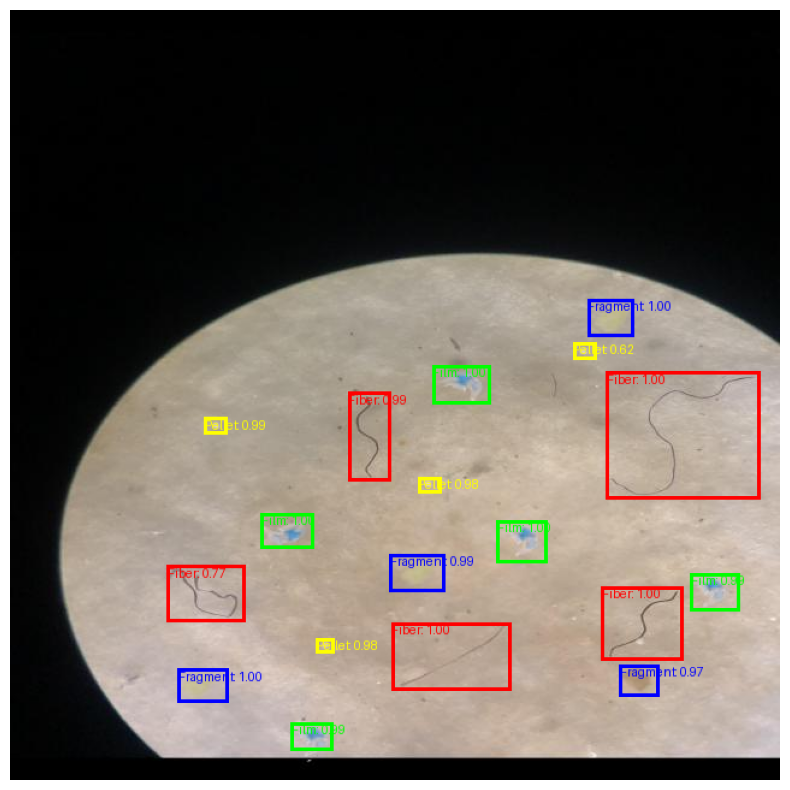

In [ ]:
import torch
import matplotlib.pyplot as plt2
from PIL import Image, ImageDraw
import torchvision.transforms as T

# Load the trained model (assuming you've saved it as 'model_final.pth')
model = torch.load('/kaggle/input/final-model-pth/model_final_new.pth', map_location='cpu', weights_only=False)
model.eval()


# If you're running on GPU, move the model to the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Preprocess the image
def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = T.Compose([T.ToTensor()])
    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return image_tensor.to(device), image

# Function to draw the boxes on the image
def draw_boxes(image, boxes, labels, scores, colors, class_names):
    draw = ImageDraw.Draw(image)
    for box, label, score in zip(boxes, labels, scores):
        x_min, y_min, x_max, y_max = box
        draw.rectangle([x_min, y_min, x_max, y_max], outline=colors[label], width=3)
        text = f"{class_names[label]}: {score:.2f}"
        draw.text((x_min, y_min), text, fill=colors[label])  # Use the same color for text
    return image

# Class names for microplastic types
class_names = ["", "Fiber", "Film", "Fragment", "Pellet"]

# Color mapping for each class (you can choose your own)
class_colors = {
    1: (255, 0, 0),  # Red for Fiber
    2: (0, 255, 0),  # Green for Film
    3: (0, 0, 255),  # Blue for Fragment
    4: (255, 255, 0),  # Yellow for Pellet
}

# Inference on a single image
def evaluate_image(image_path):
    # Preprocess the image
    image_tensor, original_image = preprocess_image(image_path)

    # Run the model to get predictions
    with torch.no_grad():
        predictions = model(image_tensor)

    # Extract the boxes, labels, and scores from the model's output
    boxes = predictions[0]['boxes'].cpu().numpy()
    labels = predictions[0]['labels'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()

    # Filter out predictions with low confidence (optional)
    threshold = 0.5  # You can adjust this value based on your needs
    high_confidence_mask = scores > threshold

    boxes = boxes[high_confidence_mask]
    labels = labels[high_confidence_mask]
    scores = scores[high_confidence_mask]

    # Draw the bounding boxes on the image
    output_image = draw_boxes(original_image, boxes, labels, scores, class_colors, class_names)

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(output_image)
    plt.axis('off')
    plt.show()

# Example usage with a path to your input image
evaluate_image("/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/test/images/100_png.rf.9cc6749d84a327fc52c47b16e1818b5f.jpg")


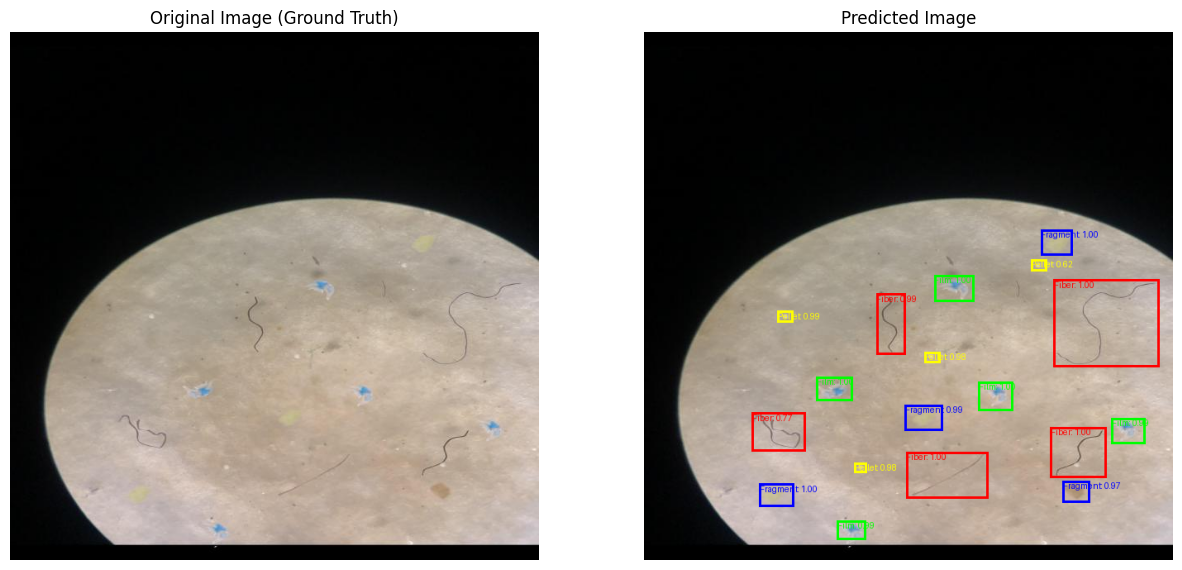

In [18]:
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import torchvision.transforms as T

# Load the trained model (assuming you've saved it as 'model_final.pth')
model = torch.load('/kaggle/input/final-model-pth/model_final_new.pth', map_location='cpu', weights_only=False)
model.eval()


# If you're running on GPU, move the model to the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Preprocess the image
def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = T.Compose([T.ToTensor()])
    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return image_tensor.to(device), image

# Function to draw the boxes on the image
def draw_boxes(image, boxes, labels, scores, colors, class_names):
    draw = ImageDraw.Draw(image)
    for box, label, score in zip(boxes, labels, scores):
        x_min, y_min, x_max, y_max = box
        draw.rectangle([x_min, y_min, x_max, y_max], outline=colors[label], width=3)
        text = f"{class_names[label]}: {score:.2f}"
        draw.text((x_min, y_min), text, fill=colors[label])  # Use the same color for text
    return image

# Class names for microplastic types
class_names = ["", "Fiber", "Film", "Fragment", "Pellet"]

# Color mapping for each class (you can choose your own)
class_colors = {
    1: (255, 0, 0),  # Red for Fiber
    2: (0, 255, 0),  # Green for Film
    3: (0, 0, 255),  # Blue for Fragment
    4: (255, 255, 0),  # Yellow for Pellet
}

# Inference on a single image
def evaluate_image(image_path):
    # Preprocess the image
    image_tensor, original_image = preprocess_image(image_path)

    # Run the model to get predictions
    with torch.no_grad():
        predictions = model(image_tensor)

    # Extract the boxes, labels, and scores from the model's output
    boxes = predictions[0]['boxes'].cpu().numpy()
    labels = predictions[0]['labels'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()

    # Filter out predictions with low confidence (optional)
    threshold = 0.5  # You can adjust this value based on your needs
    high_confidence_mask = scores > threshold

    boxes = boxes[high_confidence_mask]
    labels = labels[high_confidence_mask]
    scores = scores[high_confidence_mask]

    # Draw the bounding boxes on the predicted image
    predicted_image = draw_boxes(original_image.copy(), boxes, labels, scores, class_colors, class_names)

    # Display the images side by side
    fig, ax = plt.subplots(1, 2, figsize=(15, 10))

    # Plot original (ground truth) image on the left
    ax[0].imshow(original_image)
    ax[0].axis('off')
    ax[0].set_title("Original Image (Ground Truth)")

    # Plot predicted image on the right
    ax[1].imshow(predicted_image)
    ax[1].axis('off')
    ax[1].set_title("Predicted Image")

    plt.show()

# Example usage with a path to your input image
evaluate_image("/kaggle/input/microplastic-dataset/microplastic_100.v4i.yolov8/test/images/100_png.rf.9cc6749d84a327fc52c47b16e1818b5f.jpg")


In [6]:
!pip install torchmetrics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.4 MB/s eta 0:00:00:00:0100:01


In [29]:
pip install torchmetrics


Note: you may need to restart the kernel to use updated packages.


In [32]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def compute_map(model, dataloader, device):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5])
    with torch.no_grad():
        for images, targets in dataloader:
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images)
            
            # Ensure outputs have "boxes", "scores", and "labels"
            for output in outputs:
                if 'boxes' not in output:
                    output['boxes'] = torch.zeros((0, 4), device=device)
                if 'scores' not in output:
                    output['scores'] = torch.zeros((0,), device=device)
                if 'labels' not in output:
                    output['labels'] = torch.zeros((0,), dtype=torch.int64, device=device)

            metric.update(outputs, targets)

    result = metric.compute()
    return result["map_50"].item()



In [33]:
print("\n🔍 Final Evaluation on Test Set:")
test_precision, test_recall, test_acc = compute_metrics(model, test_loader, device, class_names=class_names)
test_mAP = compute_map(model, test_loader, device)

print(f"\n📊 Test mAP@0.5: {test_mAP:.4f}")



🔍 Final Evaluation on Test Set:

Overall Test Metrics:
Accuracy: 0.8036, Precision: 0.8738, Recall: 0.9091

Class-wise Metrics:
Fiber: Precision=1.0000, Recall=1.0000
Film: Precision=0.8621, Recall=1.0000
Fragment: Precision=0.8966, Recall=0.9286
Pellet: Precision=0.7600, Recall=0.7308

📊 Test mAP@0.5: 0.8721
